# Задание 5

Нужно построить DotPlot график синтении (выравнивания) между митохондриальным геномом неандертальца и митохондриальным геномом современного человека.

In [2]:
from Bio import SeqIO
import matplotlib.pyplot as plt

In [3]:
def plot_synteny(seq1, seq2, species1, species2, kmer_size=20):
    #создаем словарь k-меров второго генома 
    kmer_dict = {} 
    for j in range(len(seq2) - kmer_size + 1):
        kmer = seq2[j:j+kmer_size]
        if 'N' in kmer:
            continue
        if kmer in kmer_dict:
            kmer_dict[kmer].append(j)
        else:
            kmer_dict[kmer] = [j]
    
    #ищем совпадения в первом геноме
    x_coords, y_coords = [], []
    for i in range(len(seq1) - kmer_size + 1):
        kmer = seq1[i:i+kmer_size]
        if 'N' in kmer:
            continue
        if kmer in kmer_dict:
            for j in kmer_dict[kmer]:
                x_coords.append(i)
                y_coords.append(j)
    
    #строим график
    plt.figure(figsize=(10, 8))
    plt.scatter(x_coords, y_coords, s=1, c='blue', alpha=0.5)
    plt.title(f"Синтения митохондрий: {species1} vs {species2}, k = {kmer_size}")
    plt.xlabel(f"Позиция в геноме ({species1})")
    plt.ylabel(f"Позиция в геноме ({species2})")
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.show()

In [4]:
neanderthal_fasta = "NC_011137.fasta"  #митохондрия неандертальца
human_fasta = "NC_012920.fasta"        #митохондрия человека

neanderthal_seq = str(SeqIO.read(neanderthal_fasta, "fasta").seq)
human_seq = str(SeqIO.read(human_fasta, "fasta").seq)

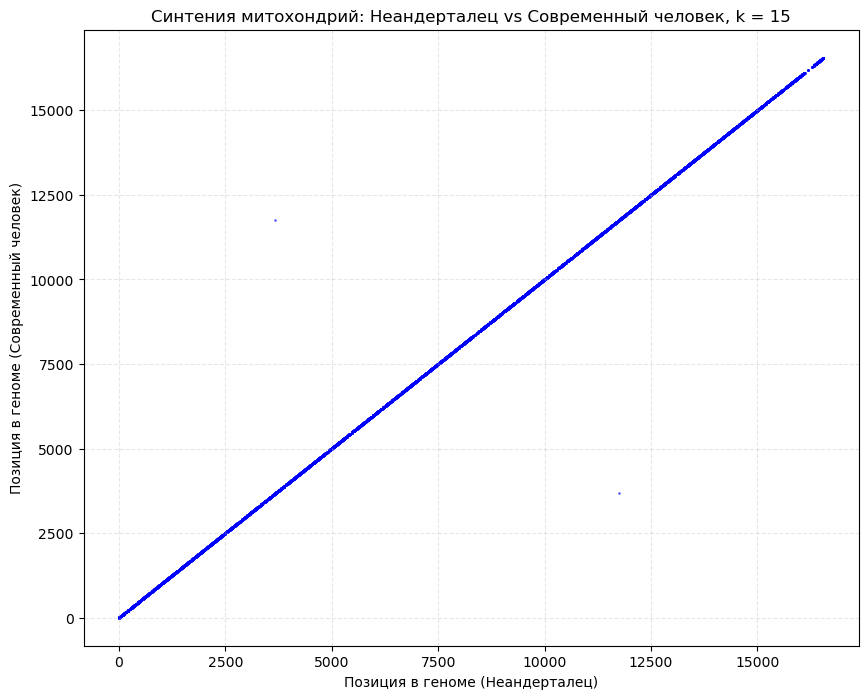

In [5]:
plot_synteny(neanderthal_seq, human_seq, "Неандерталец", "Современный человек", 15)

На графике DotPlot видна практически идеальная диагональная линия без разрывов и отклонений, что говорит о том, что крупных структурных перестроек между митохондриальными геномами неандертальца и современного человека нет. Никаких инверсий, делеций или дупликаций на графике не наблюдается — если бы они были, мы бы увидели антидиагональные линии или смещения основной диагонали. Таким образом, можно сделать вывод, что оба митохондриальных генома очень похожи по своей структуре и организации.